In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.metrics import r2_score
from sklearn.preprocessing import MinMaxScaler 
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LassoCV
import warnings
from datetime import datetime
warnings.filterwarnings("ignore")
from antenna import *

In [2]:
def traverse_tree(dt,containment_matrix,node_id, parent_id):
    if parent_id is not None:
        containment_matrix.iloc[parent_id, node_id] = 1 
        containment_matrix.iloc[:, node_id] |= containment_matrix.iloc[:, parent_id] 
    if dt.tree_.children_left[node_id] != dt.tree_.children_right[node_id]:
        traverse_tree(dt,containment_matrix,dt.tree_.children_left[node_id], node_id)
        traverse_tree(dt,containment_matrix,dt.tree_.children_right[node_id], node_id)

def get_decision_tree_boundaries(tree, feature_names, INPUT_MIN, INPUT_MAX):
    tree_ = tree.tree_
    boundaries = []

    def recurse(node, current_boundary):
        boundaries.append((node, current_boundary.copy()))

        if tree_.children_left[node] != tree_.children_right[node]:
            feature = feature_names[tree_.feature[node]]
            threshold = tree_.threshold[node]

            current_boundary_left = current_boundary.copy()
            current_boundary_left[feature] = (current_boundary_left.get(feature, (INPUT_MIN[feature_names[feature]], INPUT_MAX[feature_names[feature]]))[0], threshold)
            recurse(tree_.children_left[node], current_boundary_left)

            current_boundary_right = current_boundary.copy()
            current_boundary_right[feature] = (threshold, current_boundary_right.get(feature, (INPUT_MIN[feature_names[feature]], INPUT_MAX[feature_names[feature]]))[1])
            recurse(tree_.children_right[node], current_boundary_right)

    recurse(0, {})

    data_min = []
    data_max = []
    for node, boundary in boundaries:
        row_min = {'Node': node}
        row_max = {'Node': node}
        for i, feature in enumerate(feature_names):  # Iterate over all features
            min_val, max_val = boundary.get(feature, (INPUT_MIN[i], INPUT_MAX[i]))
            row_min[feature] = min_val
            row_max[feature] = max_val
        data_min.append(row_min)
        data_max.append(row_max)

    df_min = pd.DataFrame(data_min)
    df_min.set_index('Node', inplace=True)

    df_max = pd.DataFrame(data_max)
    df_max.set_index('Node', inplace=True)

    return df_min, df_max

In [3]:
current_ipynb_name = os.path.basename(globals()['__vsc_ipynb_file__']).split(".")[0]
current_ipynb_name

'treemodel'

In [4]:
def run(selected_geom,aedt_session):
    # sleep(i)
    
    trial_param_values = selected_geom.reshape(1,-1)
    trial_params = pd.DataFrame(trial_param_values,columns=[PARAM_NAMES_DATA2CODE[e[4:]] for e in des_cols])
    test_parameters = trial_params.iloc[0].to_dict()
    output_folderpath = "debug_reg"
    file_suffix = str(datetime.now()).replace("-","").replace(" ","").replace(".","").replace(":","")
    original_filepath_aedt = "sevenmodel_groundport_870.aedt"
    current_filepath_aedt = output_folderpath+f"/sg_{current_ipynb_name}_{file_suffix}.aedt"
    new_real,new_imag,new_mag = aedt_session.do_hfss(
        original_filepath=original_filepath_aedt,
        new_filepath=current_filepath_aedt,
        variable_values_dict=test_parameters,
        output_folder=output_folderpath,
        file_suffix=file_suffix,
        counter = 0,
    )
    # aedt_session.desktop.close_desktop()
    return selected_geom,new_mag,new_real,new_imag


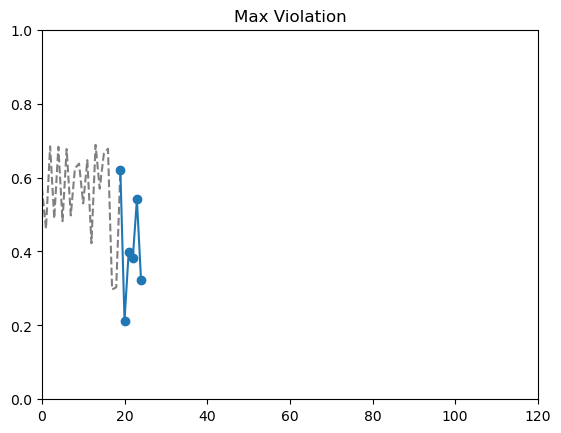

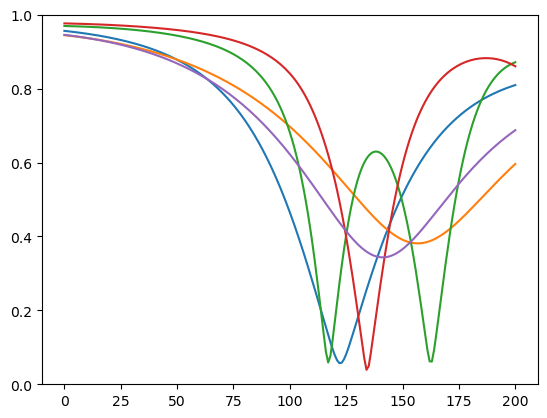

PyAEDT INFO: Python version 3.11.10 | packaged by Anaconda, Inc. | (main, Oct  3 2024, 07:22:26) [MSC v.1929 64 bit (AMD64)].
PyAEDT INFO: Parsing debug_reg/sg_treemodel_20260228151652608599.aedt.
PyAEDT INFO: PyAEDT version 0.14.0.
PyAEDT INFO: Returning found Desktop session with PID 15188!
PyAEDT INFO: Project sg_treemodel_20260228151652608599 has been opened.
PyAEDT INFO: File debug_reg/sg_treemodel_20260228151652608599.aedt correctly loaded. Elapsed time: 0m 10sec
PyAEDT INFO: Active Design set to HFSSDesign1
PyAEDT INFO: Active Design set to HFSSDesign1
PyAEDT INFO: Aedt Objects correctly read
PyAEDT INFO: Project sg_treemodel_20260228151652608599 Saved correctly
{'h_subs': 0.379999995231628, 'l_patch': 2.484, 'w_patch': 3.4, 'h_patch': 0.029, 'h_sr': 0.045, 'r_probe': 0.043, 'c_pad': 0.001, 'c_antipad': 0.0500000007450581, 'c_probe': 0.27, '$e2': 2.98, '$e1': 5.0, 'r_pad': 0.044, 'r_antipad': 0.094000000745058, 'd_probe': 0.67068}
PyAEDT INFO: Key Desktop/ActiveDSOConfigurations

In [ ]:
class Model:
    def __init__(self,params_till_now,outputs_till_now,n_components,min_samples_leaf):
        self.params_till_now = params_till_now
        self.outputs_till_now = outputs_till_now
        self.aedt_session = None
        self.update_perfs()
        self.n_components=n_components
        self.min_samples_leaf=min_samples_leaf
        self.history = []
        
        pass

    def update_perfs(self):
        self.perf_till_now = (self.outputs_till_now[:,100:151]-.3).max(1)
        self.perf2_till_now = 1-(self.outputs_till_now[:,100:151]-0.3).max(1)
        
    def set_hfss_trial(self,status: bool):
        self.hfss_trial = status
        if status == True:
            if self.aedt_session is None:
                self.aedt_session = AEDT_session()
                self.aedt_session.start_new_desktop()

    def fit_svd(self):
        self.svd = TruncatedSVD(self.n_components)
        self.svd.fit(self.outputs_till_now)
        self.coords = self.svd.transform(self.outputs_till_now)

    def fit_dt(self):
        self.dt = DecisionTreeRegressor(min_samples_leaf=self.min_samples_leaf,max_features=11,max_leaf_nodes = 9999)
        self.dt.fit(self.params_till_now,self.coords)

        n_nodes = self.dt.tree_.node_count

        containment_matrix = pd.DataFrame(np.eye(n_nodes).astype(int), index=range(n_nodes), columns=range(n_nodes))
        traverse_tree(self.dt,containment_matrix,0, None)
        containment_matrix = containment_matrix.T
        containment_matrix = containment_matrix.reset_index()
        containment_matrix.columns = ["node" if c=="index" else f"subnode_{str(c).zfill(3)}" for c in containment_matrix.columns]
        self.containment_matrix = containment_matrix

        self.subnode_df = pd.DataFrame({"node":self.dt.apply(self.params_till_now)}).merge(containment_matrix,"left")
        
        feature_names = np.arange(11)
        self.boundary_min, self.boundary_max = get_decision_tree_boundaries(self.dt, feature_names,INPUT_MIN,INPUT_MAX)

        self.two_depth_nodes = self.get_last_two_depth_nodes()

    def minmax_scale_innode(self,X,X_ref):
        scaler = MinMaxScaler()
        scaler.fit(X_ref)
        return scaler.transform(X)

    def minmax_scale_inboundary(self,X,node):
        return (X-self.boundary_min.loc[node].values)/(self.boundary_max.loc[node].values-self.boundary_min.loc[node].values)

    def get_last_two_depth_nodes(self):
        two_depth_nodes = self.containment_matrix.iloc[:,1:].sum() <= 3
        two_depth_nodes = two_depth_nodes[two_depth_nodes].index.values
        two_depth_nodes = sorted([int(e.split("_")[1]) for e in two_depth_nodes])
        return two_depth_nodes

    def search_in_nodes(self,nodes):
        candidate_geoms_all     = []
        expected_perf2_all      = []
        candidate_dists_all     = []
        candidate_stepsizes_all = []
        candidate_anchor_geoms_all = []
        candidate_anchor_mags_all = []
        candidate_anchor_perfs_all = []
        candidate_node_all = []
        candidate_reg_all = []
        for node in nodes:
            reg = self.fit_lasso(node)
            candidate_geoms,expected_perf2,candidate_dists,candidate_stepsizes, \
                candidate_anchor_geoms,candidate_anchor_mags,candidate_anchor_perfs, \
                node_idx,reg = \
                self.evaluate_points_in_node(node,reg)

            candidate_geoms_all.append(candidate_geoms)
            expected_perf2_all.append(expected_perf2)
            candidate_dists_all.append(candidate_dists)
            candidate_stepsizes_all.append(candidate_stepsizes)
            candidate_anchor_geoms_all.append(candidate_anchor_geoms)
            candidate_anchor_mags_all.append(candidate_anchor_mags)
            candidate_anchor_perfs_all.append(candidate_anchor_perfs)
            candidate_node_all.append([node]*len(candidate_geoms))
            candidate_reg_all.append([reg]*len(candidate_geoms))
            # print(node,candidate_dists)

        candidate_geoms_all = np.concatenate(candidate_geoms_all)
        expected_perf2_all = np.concatenate(expected_perf2_all)
        candidate_dists_all = np.concatenate(candidate_dists_all)
        candidate_stepsizes_all = np.concatenate(candidate_stepsizes_all)
        candidate_anchor_geoms_all = np.concatenate(candidate_anchor_geoms_all)
        candidate_anchor_mags_all = np.concatenate(candidate_anchor_mags_all)
        candidate_anchor_perfs_all = np.concatenate(candidate_anchor_perfs_all)
        candidate_node_all = np.concatenate(candidate_node_all)
        candidate_reg_all = np.concatenate(candidate_reg_all)


        return (candidate_geoms_all,expected_perf2_all,candidate_dists_all,candidate_stepsizes_all,
            candidate_anchor_geoms_all,candidate_anchor_mags_all,candidate_anchor_perfs_all,
            candidate_node_all,candidate_reg_all)

    def run(self,n_iteration):
        np.random.seed(25)
        for i in range(n_iteration):
            self.update_perfs()
            self.fit_svd()
            self.fit_dt()
            last_two_depth_nodes = self.get_last_two_depth_nodes()
            main_node = [0]
            node_sets = [last_two_depth_nodes,main_node]
            for strategy in range(2):
                node_set = node_sets[strategy]
                candidate_geoms_all,expected_perf2_all,candidate_dists_all,candidate_stepsizes_all, \
                    candidate_anchor_geoms_all,candidate_anchor_mags_all,candidate_anchor_perfs_all, \
                    candidate_node_all,candidate_reg_all = self.search_in_nodes(node_set)
                r2_scores = np.array([r.r2 for r in candidate_reg_all])
                selection = (expected_perf2_all - (1e+10)*(candidate_dists_all<=0.05)).argmax()
                if len(candidate_geoms_all) == 0:
                    if strategy == 1:
                        raise Exception("No valid candidate for Node 0")
                    continue
                else:
                    selected_geom = candidate_geoms_all[selection]
                    selected_stepsize = candidate_stepsizes_all[selection]
                    selected_anchor_geom = candidate_anchor_geoms_all[selection]
                    selected_anchor_mag = candidate_anchor_mags_all[selection]
                    selected_anchor_perf = candidate_anchor_perfs_all[selection]
                    selected_node = candidate_node_all[selection]
                    selected_reg = candidate_reg_all[selection]
                    mag_of_selected = self.get_magnitudes(selected_geom)

                    self.history.append({
                        "iter":i,"selected_geom":selected_geom,"selected_mag":mag_of_selected,
                        "anchor_geom":selected_anchor_geom,
                        "anchor_mag":selected_anchor_mag,"anchor_perf":selected_anchor_perf,
                        "node":selected_node,"reg":selected_reg,"dt":self.dt,
                        "boundary_min":self.boundary_min.copy(),"boundary_max":self.boundary_max.copy(),
                        "stepsize":selected_stepsize
                    })

                    
                    break
                

    def fit_lasso(self,node):
        node_idx = self.subnode_df[f"subnode_{str(node).zfill(3)}"].values == 1
        X_node = self.params_till_now[node_idx]
        X_node_for_reg = X_node
        X_node_for_reg = self.minmax_scale_inboundary(X_node,node)

        Y_node = self.perf2_till_now[node_idx]
        reg = LassoCV(cv=sum(node_idx),n_alphas=15, random_state=0)
        reg_vars = np.argsort(abs(pd.concat([pd.DataFrame(X_node_for_reg),pd.DataFrame(Y_node)],axis=1).corr().iloc[-1,:-1].values))[::-1][:int(len(X_node_for_reg)//2)]
        reg.fit(X_node_for_reg[:,reg_vars],Y_node)
        reg.r2 = r2_score(Y_node,reg.predict(X_node_for_reg[:,reg_vars]))
        return reg

    def evaluate_points_in_node(self,node,reg):
        node_idx = self.subnode_df[f"subnode_{str(node).zfill(3)}"].values == 1
        X_node = self.params_till_now[node_idx]
        X_node_for_reg = X_node
        X_node_for_reg = self.minmax_scale_innode(X_node,X_node)

        Y_node = self.perf2_till_now[node_idx]
        reg_vars = np.argsort(abs(pd.concat([pd.DataFrame(X_node_for_reg),pd.DataFrame(Y_node)],axis=1).corr().iloc[-1,:-1].values))[::-1][:int(len(X_node_for_reg)//2)]

        advantage_node = Y_node-reg.predict(X_node_for_reg[:,reg_vars])
        max_dist_point_details = [self.get_maxdist_point(node,reg,i) for i in range(sum(node_idx))]
        candidate_geoms = np.array([e[0] for e in max_dist_point_details])
        candidate_stepsizes = np.array([e[1] for e in max_dist_point_details])
        candidate_dists = np.array([e[2] for e in max_dist_point_details])
        candidate_anchor_geoms = np.array([e[3] for e in max_dist_point_details])
        candidate_anchor_mags = np.array([e[4] for e in max_dist_point_details])
        candidate_anchor_perfs = np.array([e[5] for e in max_dist_point_details])
        
        candidate_geoms_for_reg = self.minmax_scale_innode(candidate_geoms,X_node)
        expected_perf2 = reg.predict(candidate_geoms_for_reg[:,reg_vars])+advantage_node
        
        return (candidate_geoms,expected_perf2,candidate_dists,candidate_stepsizes,
                    candidate_anchor_geoms,candidate_anchor_mags,candidate_anchor_perfs,node_idx,reg)

        
    def get_maxdist_point(self,node,reg,anchor_idx):
        node_idx = self.subnode_df[f"subnode_{str(node).zfill(3)}"].values == 1
        X_node = self.params_till_now[node_idx]
        X_node_for_reg = self.minmax_scale_innode(X_node,X_node)

        Y_node = self.perf2_till_now[node_idx]
        anchor_geom = X_node[anchor_idx]#X_node[reg_difs_of_data_in_node.argmax()]
        anchor_mag = self.outputs_till_now[node_idx][anchor_idx]
        anchor_perf = (anchor_mag[100:151]<.3).mean()
        

        feature_min_boundary = self.boundary_min.loc[node].values
        feature_max_boundary = self.boundary_max.loc[node].values

        candidate_geom = None
        max_chebyshev = -1
        # stepsize_selected = -1
        for stepsize in np.linspace(0,1,100):
            candidate_geoms_min = anchor_geom.copy()
            candidate_geoms_max = anchor_geom.copy()

            reg_vars = np.argsort(abs(pd.concat([pd.DataFrame(X_node_for_reg),pd.DataFrame(Y_node)],axis=1).corr().iloc[-1,:-1].values))[::-1][:int(len(X_node_for_reg)//2)]

            
            candidate_geoms_min[reg_vars[reg.coef_ < 0]] = (stepsize*feature_min_boundary+(1-stepsize)*anchor_geom)[reg_vars[reg.coef_ < 0]]
            candidate_geoms_max[reg_vars[reg.coef_ > 0]] = (stepsize*feature_max_boundary+(1-stepsize)*anchor_geom)[reg_vars[reg.coef_ > 0]]

            c_candidate_geom = anchor_geom.copy()
            c_candidate_geom[reg_vars[(reg.coef_ < 0)]] = candidate_geoms_min[reg_vars[(reg.coef_ < 0)]]
            c_candidate_geom[reg_vars[(reg.coef_ > 0)]] = candidate_geoms_max[reg_vars[(reg.coef_ > 0)]]
            chebyshev_dist_to_candidate = (abs(self.params_till_now-c_candidate_geom)/(INPUT_RANGE)).max(1).min(0)
            if max_chebyshev < chebyshev_dist_to_candidate:
                max_chebyshev = chebyshev_dist_to_candidate
                candidate_geom = c_candidate_geom
                stepsize_selected = stepsize
                
        return candidate_geom,stepsize_selected,max_chebyshev,anchor_geom,anchor_mag,anchor_perf

    def get_magnitudes(self,selected_geom):
        if self.hfss_trial:
            _,mag_of_selected,_,_ = run(selected_geom,self.aedt_session)
        else:
            selected_geom_for_nn = pd.DataFrame(selected_geom,index=EXCEL_COLUMN_ORDER)#.to_dict()[0]
            selected_geom_for_nn.index = [PARAM_NAMES_DATA2CODE[e] for e in selected_geom_for_nn.index]
            selected_geom_for_nn = selected_geom_for_nn.to_dict()[0]
            _,_,mag_of_selected = emulate_nn(selected_geom_for_nn)
        
        self.params_till_now = np.vstack([self.params_till_now,selected_geom.reshape(1,-1)])
        self.outputs_till_now = np.vstack([self.outputs_till_now,mag_of_selected.reshape(1,-1)])

        self.update_perfs()

        clear_output(wait=True)
        
        perfs = (self.perf_till_now)
        plt.plot(np.arange(20),perfs[:20],"--",c="gray")
        plt.plot(np.arange(19,len(perfs)),perfs[19:],"o-")
        plt.title("Max Violation")
        plt.xlim(0,120)
        plt.ylim(0,1)
        plt.show()

        plt.plot(self.outputs_till_now[20:].T)
        plt.ylim(0,1)
        plt.show()

        return mag_of_selected
    
# lhs_seed = 0
seed = 0
lhs_seed_str = str(seed).zfill(3)
raw_real = pd.read_csv(f"data/LHS/real_initial_LHS_n20_rounded_seed{lhs_seed_str}.csv")
raw_img = pd.read_csv(f"data/LHS/imag_initial_LHS_n20_rounded_seed{lhs_seed_str}.csv")
raw_input_parameters = pd.read_csv(f"data/LHS/input_trials_done_LHS_n20_rounded_seed{lhs_seed_str}.csv")
lhs_mags = (raw_real**2+raw_img**2)**.5
lhs_mags.columns = ["sim_"+str(c).zfill(3) for c in lhs_mags.columns]
lhs_inputs = raw_input_parameters.copy()
lhs_inputs.columns = ["des_"+c for c in lhs_inputs.columns]
lhs = pd.concat([pd.concat([lhs_mags,lhs_inputs],axis=1)])
lhs

des_cols = [c for c in lhs.columns if c.startswith("des_")]
mags = lhs.iloc[:,:201].values
geoms = lhs[des_cols].values

        
model = Model(params_till_now=geoms[:20],
                outputs_till_now=mags[:20],
                n_components=15,
                min_samples_leaf=5)
model.set_hfss_trial(True)
model.run(n_iteration=100)

# print("a")

In [ ]:
model.aedt_session.desktop.close_desktop()